# Практична робота №1: аналіз і підготовка Bike Sharing Dataset

**Варіант:** 7  
**Ціль:** `cnt` — погодинна кількість оренд велосипедів.

Мета роботи — провести аудит та EDA, сформулювати гіпотези й підготувати відтворюваний preprocessing pipeline для подальшого моделювання.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.bike_workflow import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    chronological_split,
    load_bike_data,
    make_preprocessor,
    split_features_target,
)

FIGURES = Path.cwd().parent / "figures"
FIGURES.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

## 1. Формулювання задачі та опис даних

Набір описує погодинний попит на велосипеди Capital Bikeshare у 2011–2012 роках. Один рядок — одна година. Майбутня регресійна модель має передбачати `cnt`, щоб підтримувати планування доступності велосипедів і перерозподілу парку.

Джерело: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset).

In [2]:
df = load_bike_data()
print(f"Розмір таблиці: {df.shape[0]:,} рядків × {df.shape[1]} стовпців")
display(df.head())
display(df.dtypes.rename("dtype").to_frame())

Розмір таблиці: 17,379 рядків × 17 стовпців


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,dtype
instant,int64
dteday,datetime64[ns]
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


## 2. Первинний аудит даних

In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
})
print(f"Повні дублікати: {df.duplicated().sum()}")
print(f"casual + registered = cnt для всіх рядків: {bool((df.casual + df.registered == df.cnt).all())}")
display(audit)

Повні дублікати: 0
casual + registered = cnt для всіх рядків: True


,dtype,unique,missing,missing_%
instant,int64,17379,0,0.0
dteday,datetime64[ns],731,0,0.0
season,int64,4,0,0.0
yr,int64,2,0,0.0
mnth,int64,12,0,0.0
hr,int64,24,0,0.0
holiday,int64,2,0,0.0
weekday,int64,7,0,0.0
workingday,int64,2,0,0.0
weathersit,int64,4,0,0.0


Формальних пропусків і повних дублікатів немає. Проте `casual` і `registered` разом точно утворюють `cnt`; це прямий витік цільової змінної. `instant` є технічним індексом. `dteday` не подається напряму в модель, оскільки календарна інформація вже представлена `yr`, `mnth`, `weekday` та `hr`.

## 3. Числові та категоріальні ознаки

In [4]:
semantic_types = pd.DataFrame({
    "числові": pd.Series(["yr", "temp", "atemp", "hum", "windspeed", "cnt"]),
    "категоріальні": pd.Series(CATEGORICAL_FEATURES),
})
display(semantic_types)
display(df[["temp", "atemp", "hum", "windspeed", "cnt"]].describe().T)
for column in CATEGORICAL_FEATURES:
    print(f"\n{column}: {df[column].value_counts().sort_index().to_dict()}")

,числові,категоріальні
0,yr,season
1,temp,mnth
2,atemp,hr
3,hum,holiday
4,windspeed,weekday
5,cnt,workingday
6,NaN,weathersit


,count,mean,std,min,25%,50%,75%,max
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507
cnt,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,977.0000



season: {1: 4242, 2: 4409, 3: 4496, 4: 4232}

mnth: {1: 1429, 2: 1341, 3: 1473, 4: 1437, 5: 1488, 6: 1440, 7: 1488, 8: 1475, 9: 1437, 10: 1451, 11: 1437, 12: 1483}

hr: {0: 726, 1: 724, 2: 715, 3: 697, 4: 697, 5: 717, 6: 725, 7: 727, 8: 727, 9: 727, 10: 727, 11: 727, 12: 728, 13: 729, 14: 729, 15: 729, 16: 730, 17: 730, 18: 728, 19: 728, 20: 728, 21: 728, 22: 728, 23: 728}

holiday: {0: 16879, 1: 500}

weekday: {0: 2502, 1: 2479, 2: 2453, 3: 2475, 4: 2471, 5: 2487, 6: 2512}

workingday: {0: 5514, 1: 11865}

weathersit: {1: 11413, 2: 4544, 3: 1419, 4: 3}


## 4. Візуальний аналіз розподілів

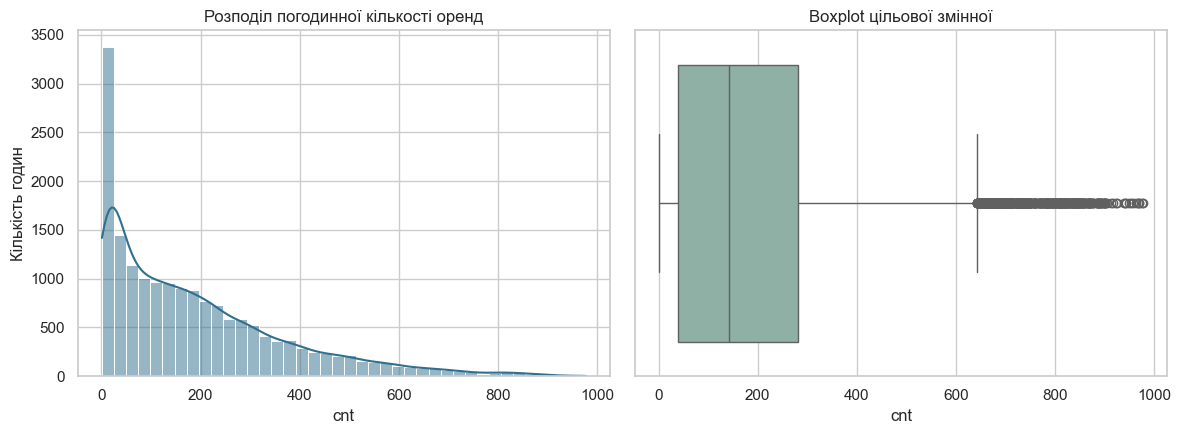

Асиметрія: 1.277
Верхня IQR-межа: 642.5; спостережень вище межі: 505


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["cnt"], bins=40, kde=True, ax=axes[0], color="#2f6f8f")
axes[0].set(title="Розподіл погодинної кількості оренд", xlabel="cnt", ylabel="Кількість годин")
sns.boxplot(x=df["cnt"], ax=axes[1], color="#89b6a5")
axes[1].set(title="Boxplot цільової змінної", xlabel="cnt")
fig.tight_layout()
fig.savefig(FIGURES / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

q1, q3 = df["cnt"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Асиметрія: {df['cnt'].skew():.3f}")
print(f"Верхня IQR-межа: {upper:.1f}; спостережень вище межі: {(df['cnt'] > upper).sum()}")

Розподіл має праву асиметрію. 505 значень вище IQR-межі не вилучаються: вони допустимі для предметної області та здебільшого відповідають реальним пікам попиту.

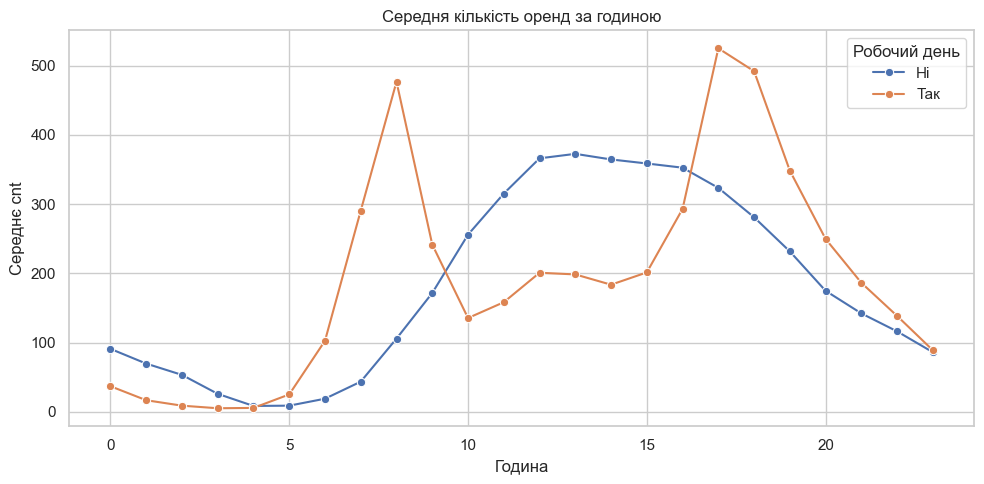

In [6]:
hourly = df.groupby(["workingday", "hr"], as_index=False)["cnt"].mean()
hourly["Робочий день"] = hourly["workingday"].map({0: "Ні", 1: "Так"})
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly, x="hr", y="cnt", hue="Робочий день", marker="o", ax=ax)
ax.set(title="Середня кількість оренд за годиною", xlabel="Година", ylabel="Середнє cnt")
fig.tight_layout()
fig.savefig(FIGURES / "hourly_profile.png", dpi=160, bbox_inches="tight")
plt.show()

У робочі дні виділяються піки близько 8:00 і 17:00–18:00. У вихідні профіль ширший і зміщений до середини дня. Отже, взаємодія `hr × workingday` є змістовною.

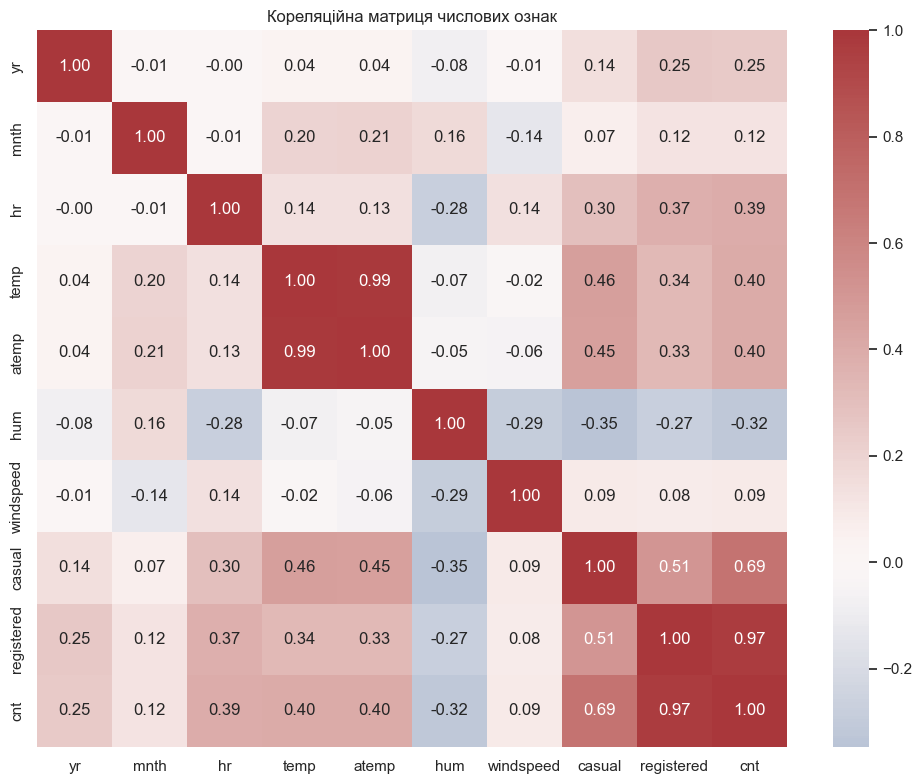

corr(temp, atemp) = 0.988


In [7]:
corr_columns = ["yr", "mnth", "hr", "temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
corr = df[corr_columns].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Кореляційна матриця числових ознак")
fig.tight_layout()
fig.savefig(FIGURES / "correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"corr(temp, atemp) = {df[['temp', 'atemp']].corr().iloc[0, 1]:.3f}")

Кореляція `temp` та `atemp` дорівнює приблизно 0,988, тому лінійні коефіцієнти можуть бути нестабільними. Обидві ознаки залишено через різний фізичний зміст, але для поліноміальної моделі застосовується Ridge. Дуже високі зв’язки `casual` і `registered` з ціллю додатково підтверджують витік.

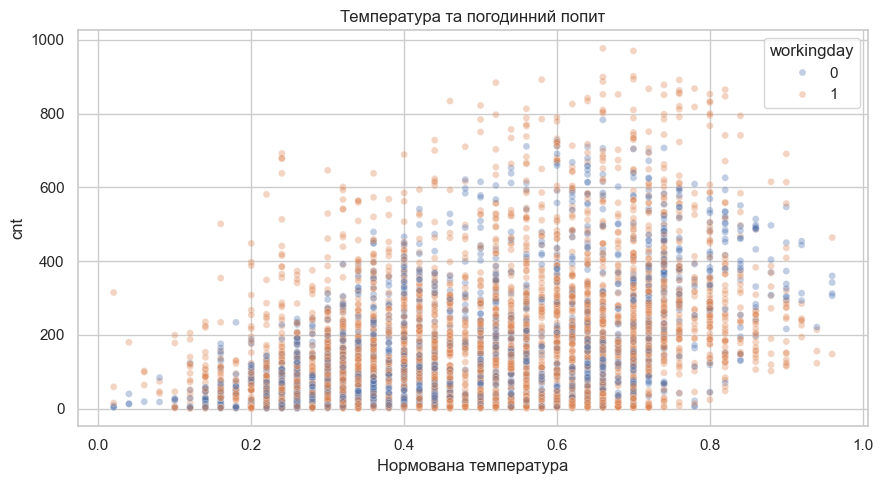

In [8]:
sample = df.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=sample, x="temp", y="cnt", hue="workingday", alpha=0.35, s=25, ax=ax)
ax.set(title="Температура та погодинний попит", xlabel="Нормована температура", ylabel="cnt")
fig.tight_layout()
fig.savefig(FIGURES / "temp_count.png", dpi=160, bbox_inches="tight")
plt.show()

Зв’язок температури з попитом позитивний, але має великий розкид і залежить від календарного режиму. Це не доказ причинності й не виглядає достатньо лінійним для однієї прямої.

## 5. Гіпотези

1. `hr` взаємодіє з `workingday`: робочі дні мають два виразні піки.
2. Вища категорія `weathersit` і вологість пов’язані зі зменшенням попиту.
3. Температурний ефект нелінійний.
4. `yr` відображає зростання популярності сервісу у 2012 році.
5. `temp` і `atemp` частково надлишкові, тому регуляризація може бути корисною.

## 6. План preprocessing

| Проблема | Рішення | Перевірка |
|---|---|---|
| службові й витокові поля | вилучити `instant`, `dteday`, `casual`, `registered` | їх немає в `X` |
| можливі майбутні пропуски чисел | медіанна імпутація | після transform немає NaN |
| різні масштаби чисел | `StandardScaler` | параметри fit лише на train |
| числові коди категорій | імпутація модою + one-hot | перевірити імена вихідних ознак |
| часовий порядок | хронологічний 80/20 split | train передує test |

In [9]:
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = chronological_split(X, y)
preprocessor = make_preprocessor()
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print(f"Train: {X_train.shape}; test: {X_test.shape}")
print(f"Період train: {df.loc[X_train.index, 'dteday'].min().date()} — {df.loc[X_train.index, 'dteday'].max().date()}")
print(f"Період test:  {df.loc[X_test.index, 'dteday'].min().date()} — {df.loc[X_test.index, 'dteday'].max().date()}")
print(f"Ознак після preprocessing: {X_train_ready.shape[1]}")
print(f"NaN у train/test: {np.isnan(X_train_ready).sum()} / {np.isnan(X_test_ready).sum()}")
display(pd.Series(preprocessor.get_feature_names_out(), name="Вихідні ознаки").to_frame())

Train: (13903, 12); test: (3476, 12)
Період train: 2011-01-01 — 2012-08-07
Період test:  2012-08-07 — 2012-12-31
Ознак після preprocessing: 60
NaN у train/test: 0 / 0


,Вихідні ознаки
0,numeric__yr
1,numeric__temp
2,numeric__atemp
3,numeric__hum
4,numeric__windspeed
5,categorical__season_1
6,categorical__season_2
7,categorical__season_3
8,categorical__season_4
9,categorical__mnth_1


## 7. Підсумкові рішення та висновки

Набір містить 17 379 повних спостережень і не потребує механічного очищення. Головні ризики — витік через компоненти цілі, часовий порядок і неправильне трактування кодів категорій як неперервних чисел. Підготовлено pipeline, який навчає всі параметри тільки на train, створює 60 ознак і без змін застосовується до test.

IQR-викиди залишено як реальні піки. Для лабораторної роботи слід перевірити нелінійність, часові взаємодії, регуляризацію та узагальнення на пізніший період. Найважливішими обмеженнями є відсутність станційних і подієвих ознак, короткий часовий горизонт і лише три години з `weathersit=4`.